In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# ==========================================================
# 2. Import Library
# ==========================================================
import os
import pandas as pd
import numpy as np
import lightgbm as lgb
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

In [3]:
# ==========================================================
# 3. Membaca Dataset
# ==========================================================
folder_path = "/content/drive/MyDrive/SKRIPSI MANTAP/data sosmed/Twitter"

embedding_df = pd.read_csv(os.path.join(folder_path, "twt_embed_lightgbm.csv"))
label_df = pd.read_csv(os.path.join(folder_path, "twt_pseudo.csv"))

print("Embedding :", embedding_df.shape)
print("Pseudo    :", label_df.shape)

Embedding : (2128, 769)
Pseudo    : (2128, 3)


In [4]:
print("Duplicate embedding :", embedding_df["twt_clean"].duplicated().sum())
print("Duplicate pseudo    :", label_df["twt_clean"].duplicated().sum())

Duplicate embedding : 36
Duplicate pseudo    : 36


In [5]:
# Menghapus duplikat berdasarkan kolom ig_clean
embedding_df = embedding_df.drop_duplicates(
    subset="twt_clean",
    keep="first"
)

label_df = label_df.drop_duplicates(
    subset="twt_clean",
    keep="first"
)

print("Embedding:", embedding_df.shape)
print("Pseudo   :", label_df.shape)

Embedding: (2092, 769)
Pseudo   : (2092, 3)


In [6]:
# ==========================================================
# 4. Merge Dataset
# ==========================================================
df = pd.merge(
    embedding_df,
    label_df[["twt_clean", "label_sentimen", "confidence_score"]],
    on="twt_clean",
    how="inner"
)

print(df.head())
print(df.shape)

                                           twt_clean     emb_0     emb_1  \
0       warga bagi-bagi dollar dari brankas sahroni.  0.339919 -0.358328   
1                              terjemahkan postingan -0.191149  0.156149   
2  man it was around 1.30ish and the satpam only ... -0.097515 -0.227882   
3  guys i also don’t know ada provokatornya atau ... -0.062315 -0.435624   
4  and i just wanted go home capek coy udah jam s...  0.554728 -0.843335   

      emb_2     emb_3     emb_4     emb_5     emb_6     emb_7     emb_8  ...  \
0 -0.758021  0.511997 -1.083653 -0.638897  0.141131  1.209347  0.333510  ...   
1 -0.780901  0.028187 -0.574339 -1.219654  0.999043  0.743064  0.467069  ...   
2 -0.204894 -0.429130 -0.630359 -0.370810  0.044485  0.528509 -0.271106  ...   
3 -0.320743  0.030373 -0.063025 -0.642756 -0.105145  0.141821 -0.129889  ...   
4 -0.056206 -0.243595 -0.197804 -0.635818  0.017982  0.719850 -0.278281  ...   

    emb_760   emb_761   emb_762   emb_763   emb_764   emb_765 

In [7]:
# ==========================================================
# 5. Filter Confidence Score
# ==========================================================
# Gunakan jika ingin hanya memakai pseudo label yang yakin

df = df[df["confidence_score"] >= 0.80].reset_index(drop=True)

print("Jumlah data setelah filter :", len(df))

Jumlah data setelah filter : 1760


In [8]:
# ==========================================================
# 6. Menentukan Feature dan Label
# ==========================================================
embedding_cols = [col for col in df.columns if col.startswith("emb_")]

X = df[embedding_cols].values

y = df["label_sentimen"]

print("Jumlah fitur :", len(embedding_cols))
print("Shape X :", X.shape)

Jumlah fitur : 768
Shape X : (1760, 768)


In [9]:
# ==========================================================
# 7. Label Encoding
# ==========================================================
encoder = LabelEncoder()

y = encoder.fit_transform(y)

print("Label kelas :", encoder.classes_)

Label kelas : ['negative' 'neutral' 'positive']


In [10]:
# ==========================================================
# 8. Train Test Split
# ==========================================================
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train :", X_train.shape)
print("Test  :", X_test.shape)

Train : (1408, 768)
Test  : (352, 768)


In [11]:
# ==========================================================
# 9. Training LightGBM
# ==========================================================
model = lgb.LGBMClassifier(
    objective="multiclass",
    num_class=3,
    learning_rate=0.05,
    n_estimators=300,
    num_leaves=31,
    random_state=42
)

model.fit(X_train, y_train)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.092279 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 195840
[LightGBM] [Info] Number of data points in the train set: 1408, number of used features: 768
[LightGBM] [Info] Start training from score -0.399799
[LightGBM] [Info] Start training from score -1.622304
[LightGBM] [Info] Start training from score -2.024179
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] N

LGBMClassifier(learning_rate=0.05, n_estimators=300, num_class=3,
               objective='multiclass', random_state=42)

In [12]:
# ==========================================================
# 10. Prediksi
# ==========================================================
y_pred = model.predict(X_test)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [13]:
# ==========================================================
# 11. Evaluasi Model
# ==========================================================
accuracy = accuracy_score(y_test, y_pred)

precision = precision_score(
    y_test,
    y_pred,
    average="weighted"
)

recall = recall_score(
    y_test,
    y_pred,
    average="weighted"
)

f1 = f1_score(
    y_test,
    y_pred,
    average="weighted"
)

print("="*50)
print("HASIL EVALUASI LIGHTGBM")
print("="*50)
print(f"Accuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1 Score  : {f1:.4f}")

HASIL EVALUASI LIGHTGBM
Accuracy  : 0.8182
Precision : 0.8203
Recall    : 0.8182
F1 Score  : 0.8012


In [14]:
# ==========================================================
# 12. Classification Report
# ==========================================================
print(classification_report(
    y_test,
    y_pred,
    target_names=encoder.classes_
))

              precision    recall  f1-score   support

    negative       0.82      0.97      0.89       236
     neutral       0.80      0.56      0.66        70
    positive       0.87      0.43      0.58        46

    accuracy                           0.82       352
   macro avg       0.83      0.65      0.71       352
weighted avg       0.82      0.82      0.80       352



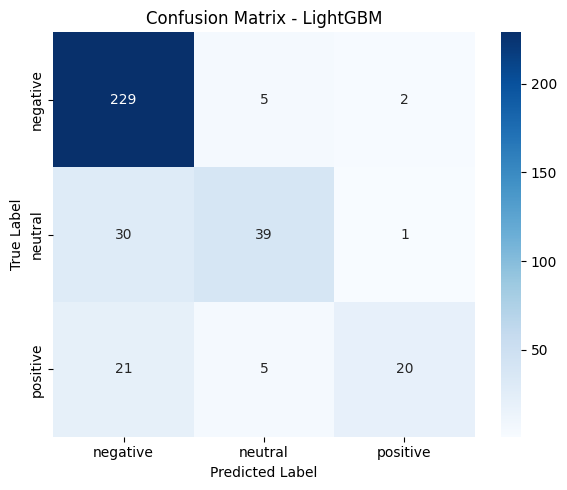

In [15]:
# ==========================================================
# 13. Confusion Matrix
# ==========================================================
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=encoder.classes_,
    yticklabels=encoder.classes_
)

plt.title("Confusion Matrix - LightGBM")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.tight_layout()
plt.show()

In [16]:
# ==========================================================
# Prediksi Seluruh Dataset
# ==========================================================
df["prediksi"] = model.predict(X)

# Mengembalikan label angka menjadi label asli
df["prediksi"] = encoder.inverse_transform(df["prediksi"])

df.head()

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


,twt_clean,emb_0,emb_1,emb_2,emb_3,emb_4,emb_5,emb_6,emb_7,emb_8,...,emb_761,emb_762,emb_763,emb_764,emb_765,emb_766,emb_767,label_sentimen,confidence_score,prediksi
0,warga bagi-bagi dollar dari brankas sahroni.,0.339919,-0.358328,-0.758021,0.511997,-1.083653,-0.638897,0.141131,1.209347,0.333510,...,-0.316782,-0.316372,-0.648051,0.288938,0.150969,-0.393444,0.383427,neutral,0.992309,neutral
1,terjemahkan postingan,-0.191149,0.156149,-0.780901,0.028187,-0.574339,-1.219654,0.999043,0.743064,0.467069,...,-0.512611,-0.332566,-0.801744,0.318051,-0.368686,-0.215100,0.028057,neutral,0.997442,negative
2,guys i also don’t know ada provokatornya atau ...,-0.062315,-0.435624,-0.320743,0.030373,-0.063025,-0.642756,-0.105145,0.141821,-0.129889,...,-0.668948,-0.394612,-0.359035,-0.272108,-0.962492,-0.690516,0.665444,negative,0.843318,negative
3,and i just wanted go home capek coy udah jam s...,0.554728,-0.843335,-0.056206,-0.243595,-0.197804,-0.635818,0.017982,0.719850,-0.278281,...,-0.127772,0.082043,-0.864247,-0.284437,-0.385573,-1.065723,0.191856,negative,0.989855,positive
4,nih deh gue share full nya aja anjir biar ga s...,0.598248,-0.140807,-0.148426,-0.051217,-0.599538,-0.586956,0.193704,0.207206,0.454978,...,0.004631,-0.767685,-0.183348,-0.263387,-0.596685,-0.667798,-0.174430,neutral,0.990264,neutral


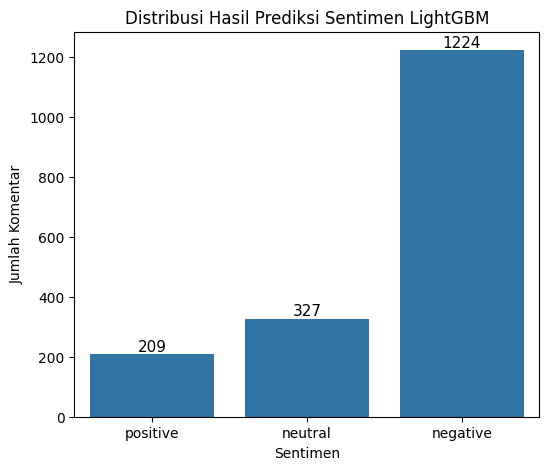

In [17]:
# ==========================================================
# Bar Chart + Jumlah
# ==========================================================
plt.figure(figsize=(6,5))

ax = sns.countplot(
    data=df,
    x="prediksi",
    order=["positive","neutral","negative"]
)

for p in ax.patches:
    ax.annotate(
        f"{int(p.get_height())}",
        (p.get_x()+p.get_width()/2,
         p.get_height()),
        ha="center",
        va="bottom",
        fontsize=11
    )

plt.title("Distribusi Hasil Prediksi Sentimen LightGBM")
plt.xlabel("Sentimen")
plt.ylabel("Jumlah Komentar")

plt.show()

In [18]:
df = df[df["confidence_score"] > 0.8].reset_index(drop=True)

print(f"Jumlah data setelah filter: {len(df):,}")
print(df["label_sentimen"].value_counts())

Jumlah data setelah filter: 1,760
label_sentimen
negative    1180
neutral      348
positive     232
Name: count, dtype: int64
